### Análise exploratória dos dados

Este notebook tem como objetivo explorar melhor o dataset selecionado na etapa anterior.

No notebook `01_dataset_validation.ipynb`, validamos que a base do Kepler possui dados suficientes para o projeto e selecionamos um primeiro conjunto de variáveis relacionadas aos objetos observados, aos possíveis exoplanetas, aos trânsitos e às estrelas hospedeiras.

Agora, nesta etapa, vamos analisar melhor essas variáveis por meio de tabelas e gráficos. O objetivo é entender padrões, diferenças entre as classes, presença de valores ausentes, possíveis outliers e relações entre as variáveis.

Essa análise é importante porque ajuda a orientar as próximas decisões do projeto, como limpeza dos dados, escolha das variáveis finais e preparação para os modelos de Machine Learning e Deep Learning.

### Importação das bibliotecas

In [2]:
%pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 29.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 33.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


### Carregamento do dataset selecionado

In [3]:
df = pd.read_csv("../data/processed/koi_selected_initial.csv")

df.head()

,kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_num_transits,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_smass,koi_kepmag,ra,dec
0,10797460,K00752.01,CONFIRMED,9.488036,2.95750,615.8,142.0,35.8,2.26,793.0,93.59,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
1,10797460,K00752.02,CONFIRMED,54.418383,4.50700,874.8,25.0,25.8,2.83,443.0,9.11,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
2,10811496,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,56.0,76.3,14.60,638.0,39.30,5853.0,4.544,0.868,0.961,15.436,297.00482,48.134129
3,10848459,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,621.0,505.6,33.46,1395.0,891.96,5805.0,4.564,0.791,0.836,15.597,285.53461,48.285210
4,10854555,K00755.01,CONFIRMED,2.525592,1.65450,603.3,515.0,40.9,2.75,1406.0,926.16,6031.0,4.438,1.046,1.095,15.509,288.75488,48.226200


In [4]:
df.shape

(9564, 18)

### Matriz de correlação das variáveis numéricas

In [7]:
%pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import seaborn as sns

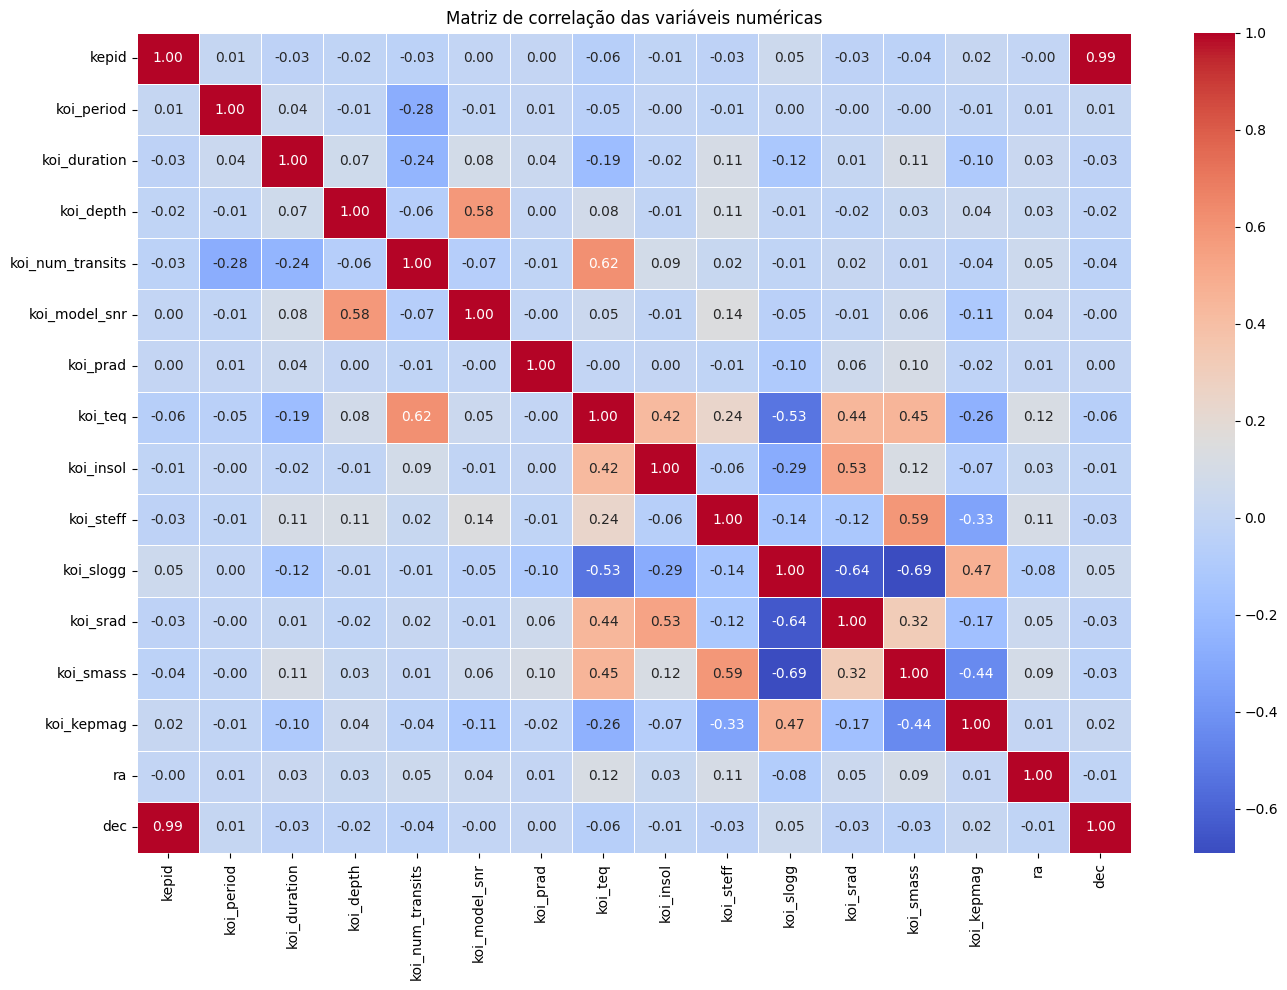

In [9]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

### Análise do mapa de correlação

O mapa de correlação mostra como as variáveis numéricas se relacionam entre si. Valores próximos de `1` indicam uma relação positiva forte, valores próximos de `-1` indicam uma relação negativa forte, e valores próximos de `0` indicam pouca relação linear entre as variáveis.

Algumas correlações chamam atenção:

- `koi_model_snr` e `koi_depth` apresentam correlação positiva moderada. Isso faz sentido, porque uma queda de brilho mais profunda tende a gerar um sinal mais fácil de detectar em relação ao ruído.
- `koi_num_transits` e `koi_teq` também apresentam correlação positiva relevante. Essa relação pode indicar padrões ligados ao período orbital e à proximidade do objeto em relação à estrela.
- Variáveis relacionadas à estrela, como `koi_steff`, `koi_slogg`, `koi_srad` e `koi_smass`, apresentam correlações entre si, o que é esperado, já que temperatura, massa, raio e gravidade da estrela são propriedades físicas conectadas.
- `koi_slogg` possui correlação negativa com `koi_srad` e `koi_smass`, indicando que estrelas maiores ou mais massivas podem apresentar menor gravidade superficial em determinados casos da amostra.

Também aparece uma correlação muito alta entre `kepid` e `dec`. Esse ponto precisa ser interpretado com cuidado, porque `kepid` é um identificador do objeto, não uma característica física que deve ser usada para prever a classe. Por isso, essa coluna deve ser mantida apenas para identificação, e não como variável de entrada para os modelos.

Essa análise ajuda a identificar variáveis relacionadas, possíveis redundâncias e colunas que precisam ser usadas com cautela. Nas próximas etapas, a correlação será útil para apoiar a seleção final das features e evitar que o modelo receba variáveis pouco informativas ou inadequadas.

### Correlações mais fortes entre as variáveis

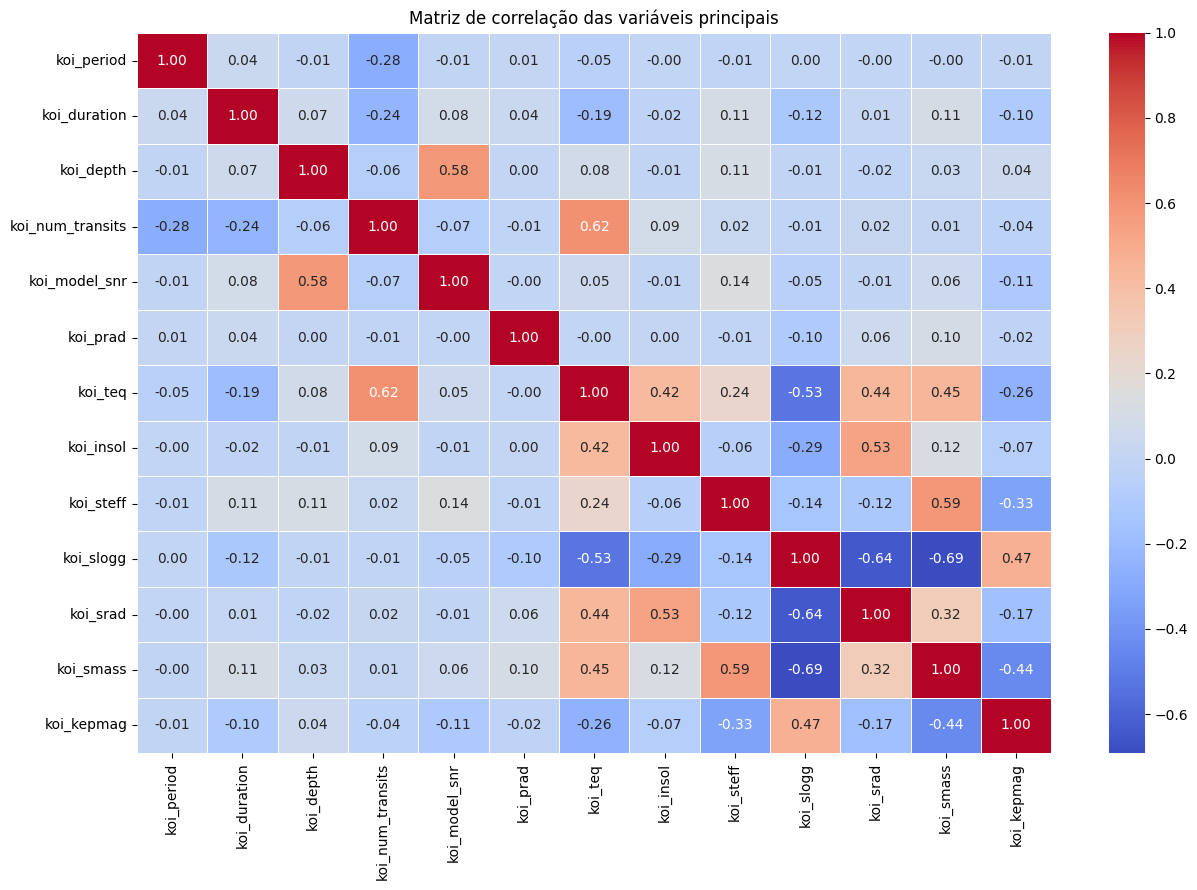

In [12]:
main_numeric_features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_num_transits",
    "koi_model_snr",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_smass",
    "koi_kepmag"
]

main_correlation_matrix = df[main_numeric_features].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    main_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlação das variáveis principais")
plt.tight_layout()
plt.show()

### Análise do mapa de correlação das variáveis principais

A matriz de correlação mostra as relações lineares entre as principais variáveis escolhidas para o projeto. Nesta versão, foram consideradas apenas variáveis ligadas ao trânsito observado, ao possível planeta, à estrela hospedeira e ao brilho medido pelo Kepler.

Algumas relações se destacam:

- `koi_depth` e `koi_model_snr` apresentam correlação positiva moderada. Isso indica que trânsitos com quedas de brilho mais profundas tendem a ter sinais mais fortes em relação ao ruído.
- `koi_num_transits` e `koi_teq` também apresentam correlação positiva relevante. Essa relação pode estar ligada ao fato de que objetos com períodos orbitais menores tendem a ser observados mais vezes e, em alguns casos, podem estar mais próximos da estrela.
- As variáveis da estrela hospedeira, como `koi_steff`, `koi_slogg`, `koi_srad` e `koi_smass`, apresentam relações importantes entre si. Isso é esperado, já que temperatura, massa, raio e gravidade superficial são propriedades físicas conectadas.
- `koi_slogg` apresenta correlação negativa com `koi_srad` e `koi_smass`, indicando que mudanças no tamanho e na massa da estrela se relacionam com sua gravidade superficial.
- `koi_kepmag` apresenta correlação moderada com algumas propriedades estelares, o que pode indicar relação entre brilho observado e características da estrela.


### Distribuição da profundidade do trânsito por classe

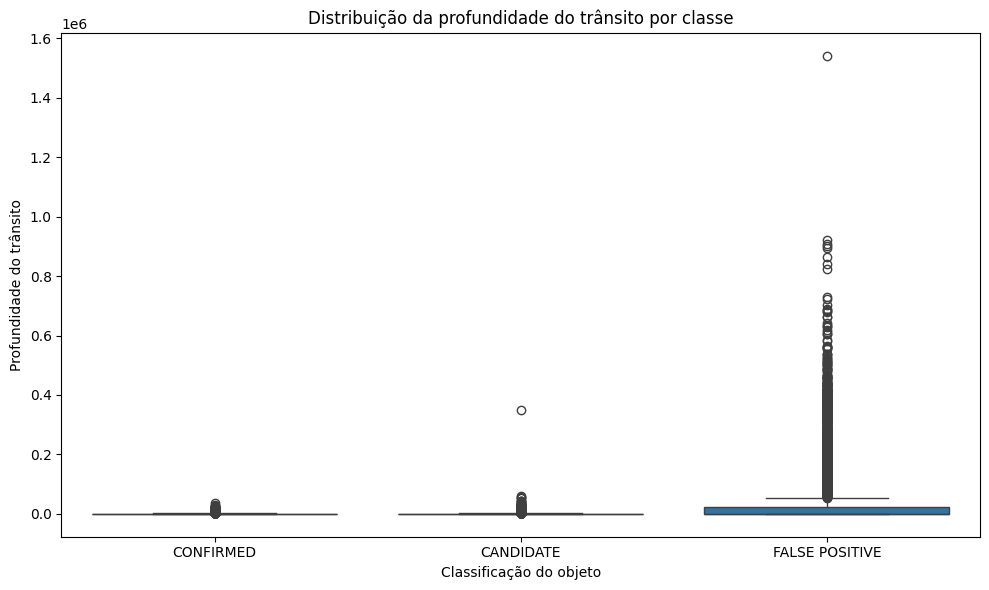

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_depth"
)

plt.title("Distribuição da profundidade do trânsito por classe")
plt.xlabel("Classificação do objeto")
plt.ylabel("Profundidade do trânsito")

plt.tight_layout()
plt.show()

### Distribuição da profundidade do trânsito por classe em escala logarítmica

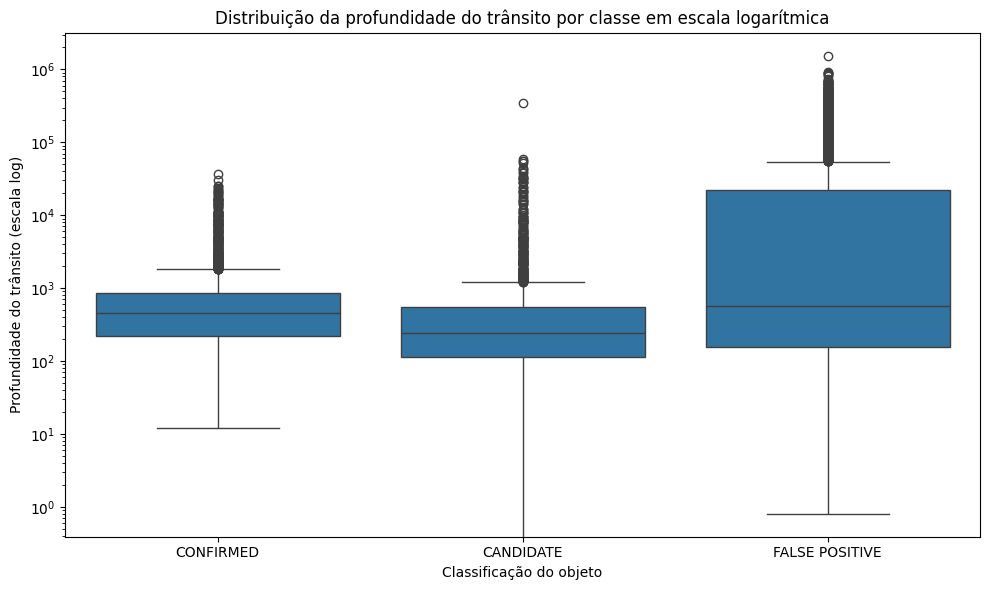

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_depth"
)

plt.yscale("log")

plt.title("Distribuição da profundidade do trânsito por classe em escala logarítmica")
plt.xlabel("Classificação do objeto")
plt.ylabel("Profundidade do trânsito (escala log)")

plt.tight_layout()
plt.show()

### Análise da profundidade do trânsito por classe

O gráfico em escala logarítmica mostra que a variável `koi_depth` apresenta diferenças importantes entre as classes.

A classe `FALSE POSITIVE` possui uma dispersão maior e valores de profundidade mais altos em comparação com `CONFIRMED` e `CANDIDATE`. Isso indica que muitos falsos positivos estão associados a quedas de brilho mais intensas.

Esse comportamento faz sentido no contexto astronômico. Um planeta geralmente causa uma queda pequena e regular no brilho da estrela. Já quedas muito profundas podem estar relacionadas a outros fenômenos, como sistemas estelares eclipsantes, que podem ser confundidos inicialmente com possíveis exoplanetas.

As classes `CONFIRMED` e `CANDIDATE` aparecem mais concentradas em valores menores de profundidade, embora também existam outliers. Isso mostra que `koi_depth` pode ser uma variável útil para os modelos, mas não deve ser usada sozinha para separar as classes.

O uso da escala logarítmica foi importante porque a variável possui muitos valores extremos. Sem essa escala, o gráfico ficava achatado e dificultava a comparação entre as classes.

### Distribuição da relação sinal-ruído por classe

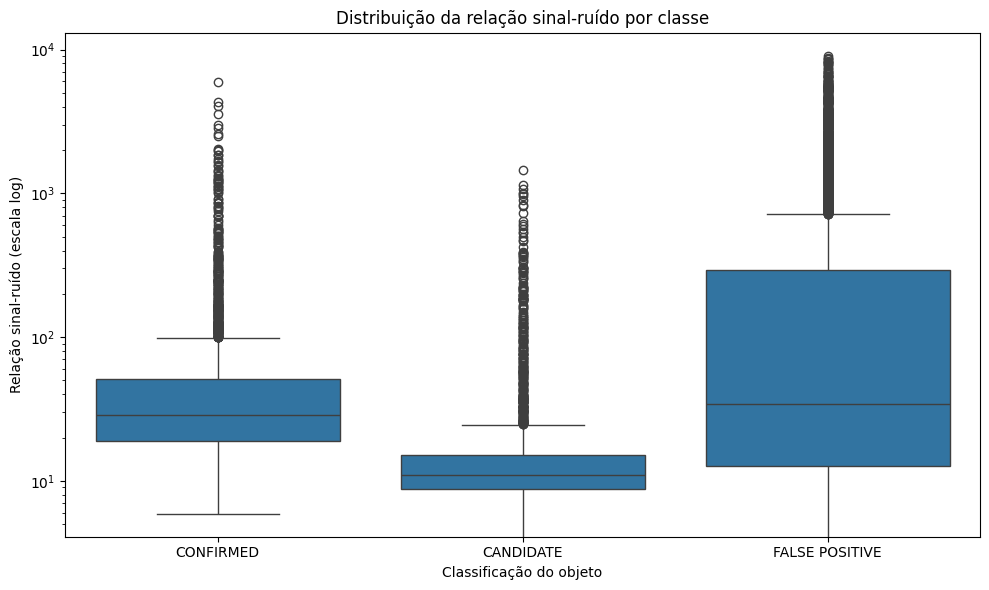

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_model_snr"
)

plt.yscale("log")

plt.title("Distribuição da relação sinal-ruído por classe")
plt.xlabel("Classificação do objeto")
plt.ylabel("Relação sinal-ruído (escala log)")

plt.tight_layout()
plt.show()

### Análise da relação sinal-ruído por classe

A variável `koi_model_snr` representa a relação sinal-ruído do modelo, ou seja, o quanto o sinal observado se destaca em relação ao ruído dos dados.

O gráfico mostra que a classe `FALSE POSITIVE` possui uma dispersão bem maior nessa variável, com muitos valores altos. Isso indica que alguns falsos positivos podem apresentar sinais muito fortes, mesmo não sendo exoplanetas reais. Esse ponto é importante porque mostra que um sinal forte, sozinho, não garante que o objeto seja um planeta confirmado.

A classe `CONFIRMED` também apresenta valores relevantes de sinal-ruído, mas com uma distribuição mais concentrada. Já a classe `CANDIDATE` aparece com valores geralmente menores e menos dispersos, o que pode indicar objetos ainda menos evidentes ou que exigem mais observações para confirmação.

Essa análise reforça que `koi_model_snr` pode ser uma variável útil para a modelagem, principalmente quando combinada com outras características, como `koi_depth`, `koi_period` e propriedades da estrela hospedeira.

### Distribuição do período orbital por classe

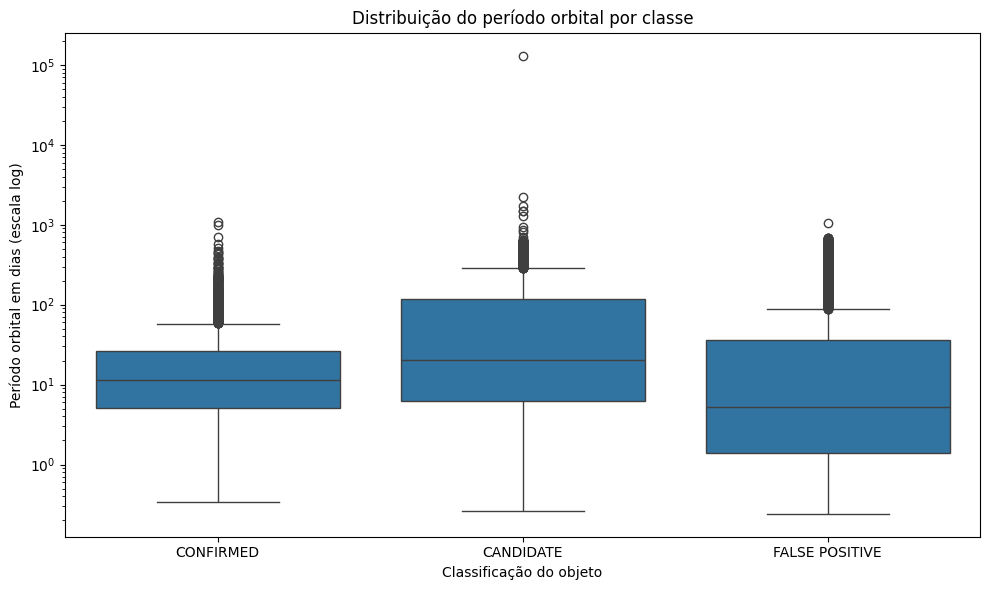

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_period"
)

plt.yscale("log")

plt.title("Distribuição do período orbital por classe")
plt.xlabel("Classificação do objeto")
plt.ylabel("Período orbital em dias (escala log)")

plt.tight_layout()
plt.show()

### Análise do período orbital por classe

A variável `koi_period` representa o período orbital estimado, ou seja, o tempo que o possível planeta leva para completar uma volta ao redor da estrela.

O gráfico mostra que a classe `CANDIDATE` apresenta uma distribuição mais ampla, com valores de período orbital mais altos em comparação com as outras classes. Isso pode indicar que alguns candidatos possuem órbitas mais longas e, por isso, podem precisar de mais tempo de observação para serem confirmados.

A classe `CONFIRMED` aparece mais concentrada em períodos menores e intermediários. Isso pode estar relacionado ao fato de que objetos com períodos orbitais menores geram trânsitos mais frequentes, facilitando a confirmação.

Já a classe `FALSE POSITIVE` também possui muitos casos com períodos curtos, mas com bastante variação. Isso mostra que o período orbital, sozinho, não separa totalmente as classes, mas pode contribuir quando combinado com outras variáveis.

O uso da escala logarítmica novamente foi importante, pois existem valores muito altos de período orbital que poderiam dificultar a leitura do gráfico em escala normal.

### Distribuição do raio estimado do possível planeta por classe

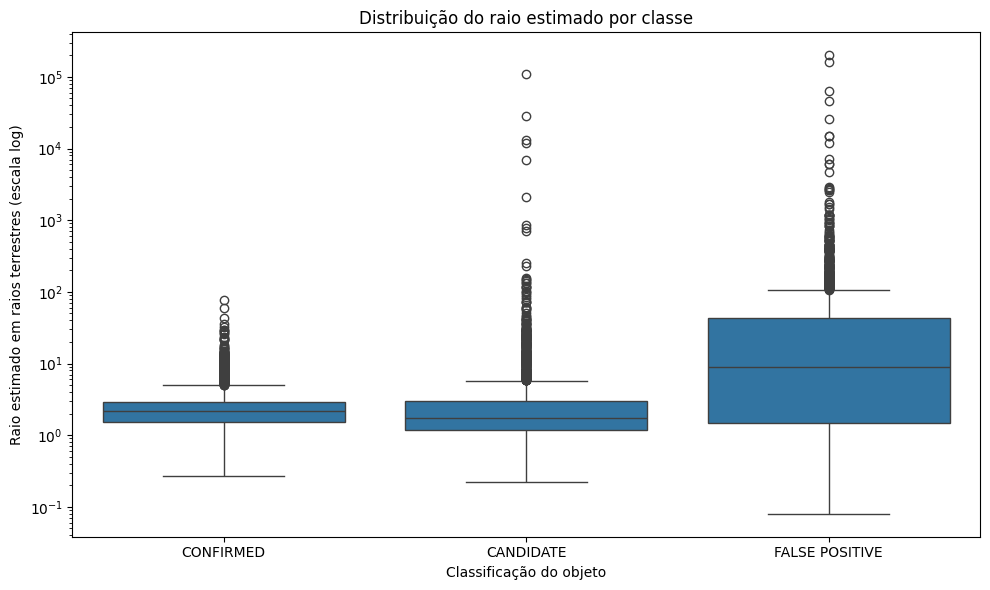

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_prad"
)

plt.yscale("log")

plt.title("Distribuição do raio estimado por classe")
plt.xlabel("Classificação do objeto")
plt.ylabel("Raio estimado em raios terrestres (escala log)")

plt.tight_layout()
plt.show()

### Análise do raio estimado por classe

A variável `koi_prad` representa o raio estimado do possível planeta, medido em relação ao raio da Terra.

O gráfico mostra que as classes `CONFIRMED` e `CANDIDATE` ficam mais concentradas em valores menores de raio. Isso indica que muitos planetas confirmados e candidatos possuem tamanhos mais compatíveis com objetos planetários.

Já a classe `FALSE POSITIVE` apresenta uma dispersão muito maior e valores de raio estimado bem mais altos. Esse comportamento é importante, porque objetos com raio extremamente grande podem ser sinais suspeitos, já que podem estar relacionados a outros fenômenos astronômicos e não necessariamente a planetas.

Essa variável parece ter bom potencial para ajudar os modelos a diferenciar objetos promissores de falsos positivos. Ainda assim, ela não deve ser usada sozinha, porque há sobreposição entre as classes e presença de outliers.

### Distribuição da temperatura da estrela por classe

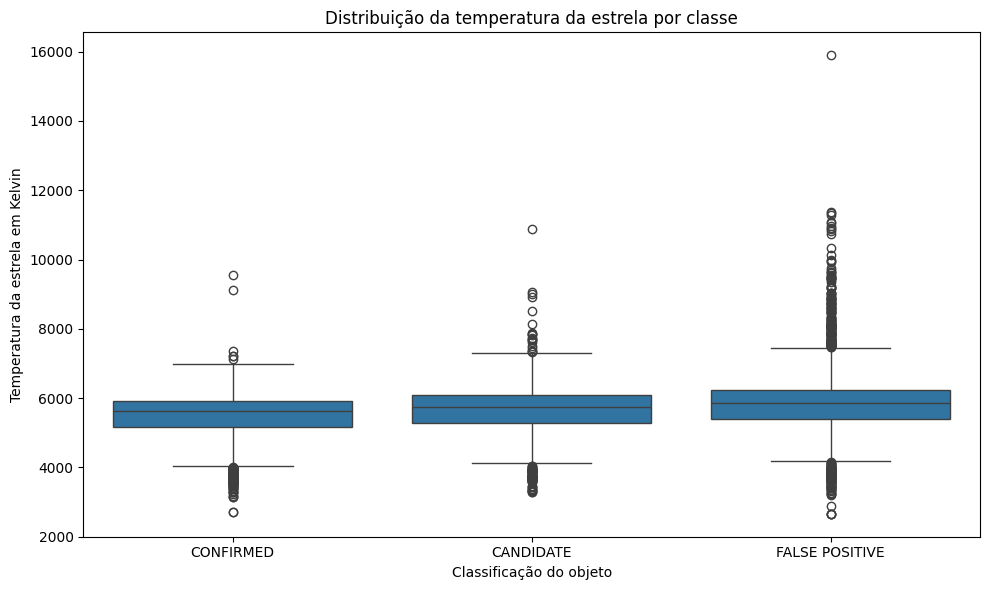

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="koi_disposition",
    y="koi_steff"
)

plt.title("Distribuição da temperatura da estrela por classe")
plt.xlabel("Classificação do objeto")
plt.ylabel("Temperatura da estrela em Kelvin")

plt.tight_layout()
plt.show()

### Análise da temperatura da estrela por classe

A variável `koi_steff` representa a temperatura efetiva da estrela hospedeira, medida em Kelvin.

O gráfico mostra que as três classes possuem distribuições relativamente próximas, principalmente na região central dos dados. Isso indica que a temperatura da estrela, sozinha, provavelmente não é suficiente para separar `CONFIRMED`, `CANDIDATE` e `FALSE POSITIVE`.

Mesmo assim, a variável continua relevante, porque ela descreve o ambiente em que o possível planeta foi observado. Além disso, a classe `FALSE POSITIVE` apresenta maior quantidade de valores extremos, incluindo estrelas com temperaturas mais altas.

Essa análise sugere que `koi_steff` pode contribuir para os modelos quando combinada com outras variáveis, mas não parece ser uma variável altamente separadora por si só.

### Estatísticas descritivas das variáveis numéricas

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
kepid,9564.0,7.690628e+06,2.653459e+06,757450.000000,5.556034e+06,7.906892e+06,9.873066e+06,1.293514e+07
koi_period,9564.0,7.567136e+01,1.334744e+03,0.241843,2.733684e+00,9.752831e+00,4.071518e+01,1.299958e+05
koi_duration,9564.0,5.621606e+00,6.471554e+00,0.052000,2.437750e+00,3.792600e+00,6.276500e+00,1.385400e+02
koi_depth,9201.0,2.379134e+04,8.224268e+04,0.000000,1.599000e+02,4.211000e+02,1.473400e+03,1.541400e+06
koi_num_transits,8422.0,3.850068e+02,5.457562e+02,0.000000,4.100000e+01,1.430000e+02,4.690000e+02,2.664000e+03
koi_model_snr,9201.0,2.598950e+02,7.958066e+02,0.000000,1.200000e+01,2.300000e+01,7.800000e+01,9.054700e+03
koi_prad,9201.0,1.028918e+02,3.077639e+03,0.080000,1.400000e+00,2.390000e+00,1.493000e+01,2.003460e+05
koi_teq,9201.0,1.085386e+03,8.563512e+02,25.000000,5.390000e+02,8.780000e+02,1.379000e+03,1.466700e+04
koi_insol,9243.0,7.745737e+03,1.592047e+05,0.000000,2.015000e+01,1.416000e+02,8.702900e+02,1.094755e+07
koi_steff,9201.0,5.706823e+03,7.968579e+02,2661.000000,5.310000e+03,5.767000e+03,6.112000e+03,1.589600e+04


### Identificação de outliers pelo método IQR

In [21]:
features_for_outliers = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_num_transits",
    "koi_model_snr",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_smass",
    "koi_kepmag"
]

outlier_summary = []

for column in features_for_outliers:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    outlier_summary.append({
        "feature": column,
        "outlier_count": len(outliers),
        "outlier_percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.sort_values("outlier_percentage", ascending=False)

,feature,outlier_count,outlier_percentage
2,koi_depth,1798,18.80
4,koi_model_snr,1600,16.73
0,koi_period,1567,16.38
5,koi_prad,1469,15.36
7,koi_insol,1438,15.04
10,koi_srad,985,10.30
3,koi_num_transits,951,9.94
1,koi_duration,869,9.09
11,koi_smass,740,7.74
9,koi_slogg,663,6.93


### Análise das estatísticas descritivas e dos outliers

As estatísticas descritivas mostram que várias variáveis possuem grande diferença entre média e mediana. Isso indica que a distribuição dos dados não é totalmente simétrica e que existem valores extremos, também chamados de `outliers`.

Esse comportamento aparece principalmente em variáveis como `koi_period`, `koi_depth`, `koi_model_snr`, `koi_prad` e `koi_insol`. Por exemplo, em `koi_prad`, a mediana é bem menor que a média, o que indica que alguns valores muito altos estão puxando a média para cima.

A análise pelo método IQR confirma esse padrão de forma mais objetiva. As variáveis com maior percentual de outliers foram `koi_depth` com 18,80%, `koi_model_snr` com 16,73%, `koi_period` com 16,38%, `koi_prad` com 15,36% e `koi_insol` com 15,04%.

Esses resultados fazem sentido com o que foi observado nos boxplots. Variáveis ligadas ao trânsito, ao sinal detectado e às propriedades estimadas do possível planeta apresentam maior variação e mais valores extremos, principalmente nos casos classificados como `FALSE POSITIVE`.

Para a modelagem, isso é um ponto importante. Os outliers não devem ser removidos automaticamente, porque podem representar casos reais e relevantes do fenômeno estudado. Porém, será necessário tratar esses dados com cuidado nas próximas etapas, avaliando transformações como escala logarítmica, normalização e escolha de modelos menos sensíveis a valores extremos.

Essa análise reforça que o dataset possui informações úteis, mas também exige uma preparação adequada antes dos modelos de Machine Learning e Deep Learning.

### Conclusão da análise exploratória

A análise exploratória mostrou que o dataset possui variáveis relevantes para apoiar a classificação dos objetos observados pela missão Kepler.

Com base nessa análise, o dataset continua adequado para o projeto. A próxima etapa será iniciar o notebook de Machine Learning, preparando os dados para modelagem, tratando valores ausentes e treinando os primeiros modelos baseline.